In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
final_df = pd.read_csv('최종전처리.csv', encoding='CP949')
final_df

,Unnamed: 0,시도,일시,fire,평균기온(°C),최고기온(°C),일강수량(mm),평균 상대습도(%),최대 풍속(m/s),평균 풍속(m/s),최저기온(°C),일 최심적설(cm),실효습도,년도,논_비율,밭_비율,도시_산림_인접지수
0,0,경북,2016-01-03,1,4.376923,16.3,0.0,72.415385,6.5,1.184615,-6.6,0.0,59.201499,2016,14.049405,19.069746,10.158780
1,1,경북,2016-01-04,0,5.192308,12.9,0.0,50.807692,8.3,2.715385,-6.2,0.0,55.198808,2016,14.049405,19.069746,10.158780
2,2,경북,2016-01-05,0,0.423077,7.0,0.0,33.076923,8.1,2.646154,-7.0,0.0,46.443746,2016,14.049405,19.069746,10.158780
3,3,경북,2016-01-06,1,0.084615,7.0,0.0,46.515385,9.6,2.976923,-9.8,0.0,43.977776,2016,14.049405,19.069746,10.158780
4,4,경북,2016-01-07,0,-0.030769,6.4,0.0,44.192308,8.1,3.092308,-9.2,0.0,41.731961,2016,14.049405,19.069746,10.158780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62013,63262,제주,2025-12-27,0,4.200000,9.4,0.0,59.325000,6.1,2.625000,-2.8,0.0,54.115659,2025,0.001604,7.444119,6.744372
62014,63263,제주,2025-12-28,0,8.950000,13.7,0.0,53.875000,12.7,2.800000,1.0,0.0,51.877249,2025,0.001604,7.444119,6.744372
62015,63264,제주,2025-12-29,0,12.325000,17.3,0.0,60.600000,11.5,4.400000,5.0,0.0,52.197272,2025,0.001604,7.444119,6.744372
62016,63265,제주,2025-12-30,0,8.325000,15.8,0.0,51.725000,10.3,3.700000,3.6,0.0,49.414664,2025,0.001604,7.444119,6.744372


In [26]:
X = final_df.drop(['fire','시도','Unnamed: 0','일시','최고기온(°C)','최저기온(°C)'], axis=1)
y = final_df['fire']



In [29]:
# 데이터 분할 (학습, 평가)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0,test_size=0.2,stratify=y)
print(X_train.shape)
smote = SMOTE(random_state=42)
X_resample, y_resample = smote.fit_resample(X_train,y_train)

print(f'resample 후 샘플 비율 : {np.bincount(y_resample)}')
X_resample.shape, y_resample.shape

# 데이터 분할 (학습, 검증)
X_tr, X_eval, y_tr, y_eval = train_test_split(X_resample, y_resample, random_state=0)






(49614, 11)
resample 후 샘플 비율 : [45542 45542]


##### lightGBM 기본적으로 많이 사용하는 하이퍼파라미터 
| 파라미터                  | 디폴트값    | 권장 범위      | 설명                                                                 |
| --------------------- | ------- | ---------- | ------------------------------------------------------------------ |
| **learning_rate**     | **0.1** | 0.01 – 0.2 | 각 트리가 전체 모델에 기여하는 비율. 작을수록 안정적이나 더 많은 트리가 필요하며, 클수록 빠르지만 과적합 위험 증가 |
| **n_estimators**      | **100** | 100 – 2000 | 생성할 부스팅 트리 개수. `learning_rate`가 작을수록 더 큰 값이 필요                     |
| **num_leaves**        | **31**  | 20 – 150   | 하나의 트리가 가질 수 있는 최대 리프 수. 값이 클수록 표현력 증가, 과적합 위험 증가                  |
| **min_child_samples** | **20**  | 5 – 100    | 하나의 리프 노드에 포함되어야 하는 최소 샘플 수. 값이 클수록 트리가 보수적으로 성장                   |
| **subsample**         | **1.0** | 0.5 – 1.0  | 각 트리 학습 시 사용하는 데이터 비율(행 샘플링). 낮추면 분산 감소 및 과적합 완화                   |
| **colsample_bytree**  | **1.0** | 0.5 – 1.0  | 각 트리 학습 시 사용하는 feature 비율(열 샘플링). 낮추면 트리 간 다양성 증가                  |
| **reg_alpha**         | **0.0** | 0.0 – 1.0  | L1 정규화 계수. 리프 가중치의 희소성을 증가시켜 불필요한 분기 제거                            |
| **reg_lambda**        | **0.0** | 0.0 – 1.0  | L2 정규화 계수. 리프 가중치를 완만하게 제한하여 모델 안정성 향상                             |


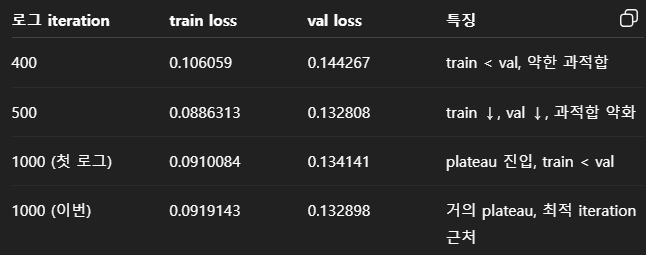

In [75]:

from sklearn.model_selection import cross_val_score
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, roc_auc_score


eval_set = [(X_tr,y_tr), (X_eval,y_eval)] # 2개의 검증 셋(학습, 검증)


def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'objective': 'binary',
        'metric': 'binary_logloss',
        'early_stopping_rounds': trial.suggest_int('early_stopping_rounds', 100, 1000)
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_eval, y_eval)],
    )

    preds = model.predict_proba(X_eval)[:, 1]
    return roc_auc_score(y_eval, preds)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)





[I 2026-02-10 20:36:07,955] A new study created in memory with name: no-name-c032d05b-fa98-43fd-a8e7-f3b6ba88a4d9


Training until validation scores don't improve for 731 rounds


[I 2026-02-10 20:36:09,478] Trial 0 finished with value: 0.985133692019377 and parameters: {'n_estimators': 500, 'learning_rate': 0.061072552403589775, 'num_leaves': 23, 'min_child_samples': 44, 'subsample': 0.887593710152083, 'colsample_bytree': 0.9166485491603682, 'reg_alpha': 0.21237883350054743, 'reg_lambda': 0.5128411941576358, 'early_stopping_rounds': 731}. Best is trial 0 with value: 0.985133692019377.


Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.171176
Training until validation scores don't improve for 973 rounds
Did not meet early stopping. Best iteration is:
[900]	valid_0's binary_logloss: 0.118478


[I 2026-02-10 20:36:12,230] Trial 1 finished with value: 0.9922693788327138 and parameters: {'n_estimators': 900, 'learning_rate': 0.06352274908796625, 'num_leaves': 37, 'min_child_samples': 47, 'subsample': 0.7036244201932734, 'colsample_bytree': 0.7944227169432635, 'reg_alpha': 0.13534503466234882, 'reg_lambda': 0.3652575020648745, 'early_stopping_rounds': 973}. Best is trial 1 with value: 0.9922693788327138.


Training until validation scores don't improve for 822 rounds
Did not meet early stopping. Best iteration is:
[1700]	valid_0's binary_logloss: 0.143271


[I 2026-02-10 20:36:15,904] Trial 2 finished with value: 0.9892230180943172 and parameters: {'n_estimators': 1700, 'learning_rate': 0.03483803558114729, 'num_leaves': 20, 'min_child_samples': 74, 'subsample': 0.8118924995518215, 'colsample_bytree': 0.8816739333398443, 'reg_alpha': 0.6468604572851273, 'reg_lambda': 0.6543985557859587, 'early_stopping_rounds': 822}. Best is trial 1 with value: 0.9922693788327138.


Training until validation scores don't improve for 919 rounds
Did not meet early stopping. Best iteration is:
[1300]	valid_0's binary_logloss: 0.0969488


[I 2026-02-10 20:36:22,274] Trial 3 finished with value: 0.9943058608574591 and parameters: {'n_estimators': 1300, 'learning_rate': 0.04126359742220137, 'num_leaves': 91, 'min_child_samples': 41, 'subsample': 0.6230169617776176, 'colsample_bytree': 0.7239342480909472, 'reg_alpha': 0.9906617227879398, 'reg_lambda': 0.9806486782669704, 'early_stopping_rounds': 919}. Best is trial 3 with value: 0.9943058608574591.


Training until validation scores don't improve for 763 rounds
Early stopping, best iteration is:
[649]	valid_0's binary_logloss: 0.0907162


[I 2026-02-10 20:36:27,712] Trial 4 finished with value: 0.9948366431116243 and parameters: {'n_estimators': 2000, 'learning_rate': 0.18714040313505842, 'num_leaves': 69, 'min_child_samples': 32, 'subsample': 0.8547170210032281, 'colsample_bytree': 0.8941858077134739, 'reg_alpha': 0.07868413246210082, 'reg_lambda': 0.4766482355451418, 'early_stopping_rounds': 763}. Best is trial 4 with value: 0.9948366431116243.


Training until validation scores don't improve for 855 rounds
Did not meet early stopping. Best iteration is:
[400]	valid_0's binary_logloss: 0.0973626


[I 2026-02-10 20:36:29,965] Trial 5 finished with value: 0.9940886802339358 and parameters: {'n_estimators': 400, 'learning_rate': 0.13186720478476854, 'num_leaves': 88, 'min_child_samples': 90, 'subsample': 0.9653785069983352, 'colsample_bytree': 0.9475756874236079, 'reg_alpha': 0.7225610653903353, 'reg_lambda': 0.47846439963165455, 'early_stopping_rounds': 855}. Best is trial 4 with value: 0.9948366431116243.


Training until validation scores don't improve for 158 rounds
Did not meet early stopping. Best iteration is:
[400]	valid_0's binary_logloss: 0.155084


[I 2026-02-10 20:36:32,627] Trial 6 finished with value: 0.9882537320152335 and parameters: {'n_estimators': 400, 'learning_rate': 0.02760888913327024, 'num_leaves': 96, 'min_child_samples': 95, 'subsample': 0.6413028816726501, 'colsample_bytree': 0.6080390412296466, 'reg_alpha': 0.9338994828221413, 'reg_lambda': 0.9101851907367768, 'early_stopping_rounds': 158}. Best is trial 4 with value: 0.9948366431116243.


Training until validation scores don't improve for 269 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's binary_logloss: 0.0929365


[I 2026-02-10 20:36:38,008] Trial 7 finished with value: 0.9945323140668337 and parameters: {'n_estimators': 1000, 'learning_rate': 0.059915316513930346, 'num_leaves': 92, 'min_child_samples': 60, 'subsample': 0.7893321220163956, 'colsample_bytree': 0.8738065938216071, 'reg_alpha': 0.8740248642718285, 'reg_lambda': 0.0020306895018116222, 'early_stopping_rounds': 269}. Best is trial 4 with value: 0.9948366431116243.


Training until validation scores don't improve for 445 rounds


[I 2026-02-10 20:36:39,647] Trial 8 finished with value: 0.9934383186509161 and parameters: {'n_estimators': 300, 'learning_rate': 0.12295276540690592, 'num_leaves': 85, 'min_child_samples': 79, 'subsample': 0.965145362101496, 'colsample_bytree': 0.8361208201834426, 'reg_alpha': 0.1659497721731954, 'reg_lambda': 0.8984474900090333, 'early_stopping_rounds': 445}. Best is trial 4 with value: 0.9948366431116243.


Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.106202
Training until validation scores don't improve for 778 rounds
Did not meet early stopping. Best iteration is:
[1300]	valid_0's binary_logloss: 0.118322


[I 2026-02-10 20:36:42,989] Trial 9 finished with value: 0.9921136503047748 and parameters: {'n_estimators': 1300, 'learning_rate': 0.06226814020793083, 'num_leaves': 26, 'min_child_samples': 88, 'subsample': 0.7153851248805291, 'colsample_bytree': 0.6856400860689061, 'reg_alpha': 0.6406813585621143, 'reg_lambda': 0.12291181196465895, 'early_stopping_rounds': 778}. Best is trial 4 with value: 0.9948366431116243.


Training until validation scores don't improve for 588 rounds
Early stopping, best iteration is:
[655]	valid_0's binary_logloss: 0.0904594


[I 2026-02-10 20:36:47,839] Trial 10 finished with value: 0.9948216542311673 and parameters: {'n_estimators': 2000, 'learning_rate': 0.19511691643054765, 'num_leaves': 63, 'min_child_samples': 15, 'subsample': 0.886134514879761, 'colsample_bytree': 0.9873212050984749, 'reg_alpha': 0.3581204287791441, 'reg_lambda': 0.2802979747887425, 'early_stopping_rounds': 588}. Best is trial 4 with value: 0.9948366431116243.


Training until validation scores don't improve for 578 rounds
Early stopping, best iteration is:
[705]	valid_0's binary_logloss: 0.0901821


[I 2026-02-10 20:36:53,690] Trial 11 finished with value: 0.9949182989529197 and parameters: {'n_estimators': 2000, 'learning_rate': 0.19952211746789492, 'num_leaves': 64, 'min_child_samples': 12, 'subsample': 0.8787215114745958, 'colsample_bytree': 0.9990269802099936, 'reg_alpha': 0.3820121445937585, 'reg_lambda': 0.22363225270785134, 'early_stopping_rounds': 578}. Best is trial 11 with value: 0.9949182989529197.


Training until validation scores don't improve for 611 rounds
Early stopping, best iteration is:
[651]	valid_0's binary_logloss: 0.0904468


[I 2026-02-10 20:36:58,537] Trial 12 finished with value: 0.9949887613482333 and parameters: {'n_estimators': 2000, 'learning_rate': 0.19643324407903612, 'num_leaves': 65, 'min_child_samples': 11, 'subsample': 0.8680667901737891, 'colsample_bytree': 0.9928557983145685, 'reg_alpha': 0.0003401374638237753, 'reg_lambda': 0.22136288527379583, 'early_stopping_rounds': 611}. Best is trial 12 with value: 0.9949887613482333.


Training until validation scores don't improve for 550 rounds
Early stopping, best iteration is:
[990]	valid_0's binary_logloss: 0.0906914


[I 2026-02-10 20:37:04,621] Trial 13 finished with value: 0.9947228186488642 and parameters: {'n_estimators': 1700, 'learning_rate': 0.16055420613574103, 'num_leaves': 50, 'min_child_samples': 12, 'subsample': 0.9172892544807882, 'colsample_bytree': 0.9932391891531195, 'reg_alpha': 0.4004841869633863, 'reg_lambda': 0.19678872243179263, 'early_stopping_rounds': 550}. Best is trial 12 with value: 0.9949887613482333.


Training until validation scores don't improve for 419 rounds
Early stopping, best iteration is:
[678]	valid_0's binary_logloss: 0.0888482


[I 2026-02-10 20:37:09,574] Trial 14 finished with value: 0.9950796897753803 and parameters: {'n_estimators': 1700, 'learning_rate': 0.16817534964300535, 'num_leaves': 73, 'min_child_samples': 26, 'subsample': 0.8109027221871608, 'colsample_bytree': 0.9997229841105957, 'reg_alpha': 0.2835433900508121, 'reg_lambda': 0.024036480212875938, 'early_stopping_rounds': 419}. Best is trial 14 with value: 0.9950796897753803.


Training until validation scores don't improve for 355 rounds
Early stopping, best iteration is:
[648]	valid_0's binary_logloss: 0.0899154


[I 2026-02-10 20:37:14,692] Trial 15 finished with value: 0.9949981187913596 and parameters: {'n_estimators': 1600, 'learning_rate': 0.1629562348490826, 'num_leaves': 77, 'min_child_samples': 27, 'subsample': 0.7829178233036458, 'colsample_bytree': 0.946124310468255, 'reg_alpha': 0.027550610670898645, 'reg_lambda': 0.004140073240405467, 'early_stopping_rounds': 355}. Best is trial 14 with value: 0.9950796897753803.


Training until validation scores don't improve for 381 rounds
Early stopping, best iteration is:
[737]	valid_0's binary_logloss: 0.0887749


[I 2026-02-10 20:37:20,405] Trial 16 finished with value: 0.9950925109381799 and parameters: {'n_estimators': 1700, 'learning_rate': 0.1574277719024107, 'num_leaves': 76, 'min_child_samples': 30, 'subsample': 0.7701337977926991, 'colsample_bytree': 0.7927646591958879, 'reg_alpha': 0.2675443996740763, 'reg_lambda': 0.017304810196462225, 'early_stopping_rounds': 381}. Best is trial 16 with value: 0.9950925109381799.


Training until validation scores don't improve for 437 rounds
Did not meet early stopping. Best iteration is:
[1492]	valid_0's binary_logloss: 0.0897245


[I 2026-02-10 20:37:26,415] Trial 17 finished with value: 0.9947780221633008 and parameters: {'n_estimators': 1500, 'learning_rate': 0.09492719597807567, 'num_leaves': 52, 'min_child_samples': 29, 'subsample': 0.7287655637326329, 'colsample_bytree': 0.7768784537187423, 'reg_alpha': 0.23093218058526999, 'reg_lambda': 0.06696706339401276, 'early_stopping_rounds': 437}. Best is trial 16 with value: 0.9950925109381799.


Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[810]	valid_0's binary_logloss: 0.0920463


[I 2026-02-10 20:37:31,776] Trial 18 finished with value: 0.9946132910499305 and parameters: {'n_estimators': 1400, 'learning_rate': 0.1548188751722791, 'num_leaves': 74, 'min_child_samples': 61, 'subsample': 0.7554742272161056, 'colsample_bytree': 0.7457712480298461, 'reg_alpha': 0.5103425729839345, 'reg_lambda': 0.6710666212354814, 'early_stopping_rounds': 150}. Best is trial 16 with value: 0.9950925109381799.


Training until validation scores don't improve for 297 rounds
Did not meet early stopping. Best iteration is:
[1080]	valid_0's binary_logloss: 0.0872155


[I 2026-02-10 20:37:37,662] Trial 19 finished with value: 0.9951651333368532 and parameters: {'n_estimators': 1100, 'learning_rate': 0.10372781004758225, 'num_leaves': 79, 'min_child_samples': 26, 'subsample': 0.6629868975733868, 'colsample_bytree': 0.8364476405875716, 'reg_alpha': 0.30109114057862746, 'reg_lambda': 0.34112177968026985, 'early_stopping_rounds': 297}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 263 rounds
Did not meet early stopping. Best iteration is:
[700]	valid_0's binary_logloss: 0.0936166


[I 2026-02-10 20:37:41,656] Trial 20 finished with value: 0.9944271064746192 and parameters: {'n_estimators': 700, 'learning_rate': 0.09550309604808105, 'num_leaves': 79, 'min_child_samples': 52, 'subsample': 0.6588658746101469, 'colsample_bytree': 0.8211865096191046, 'reg_alpha': 0.4936719614160663, 'reg_lambda': 0.36135814549324863, 'early_stopping_rounds': 263}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 371 rounds
Did not meet early stopping. Best iteration is:
[910]	valid_0's binary_logloss: 0.0889653


[I 2026-02-10 20:37:47,717] Trial 21 finished with value: 0.9949938759276172 and parameters: {'n_estimators': 1100, 'learning_rate': 0.1177421168508064, 'num_leaves': 81, 'min_child_samples': 22, 'subsample': 0.8250105172952686, 'colsample_bytree': 0.6787028785419257, 'reg_alpha': 0.27891566489753644, 'reg_lambda': 0.12215268394050767, 'early_stopping_rounds': 371}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 265 rounds
Early stopping, best iteration is:
[1037]	valid_0's binary_logloss: 0.0903188


[I 2026-02-10 20:37:52,507] Trial 22 finished with value: 0.9947514926934647 and parameters: {'n_estimators': 1800, 'learning_rate': 0.1450046149363112, 'num_leaves': 53, 'min_child_samples': 35, 'subsample': 0.6835806454647034, 'colsample_bytree': 0.8456851064174414, 'reg_alpha': 0.32064994343762604, 'reg_lambda': 0.11763663675531344, 'early_stopping_rounds': 265}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 478 rounds
Did not meet early stopping. Best iteration is:
[753]	valid_0's binary_logloss: 0.0915249


[I 2026-02-10 20:37:55,941] Trial 23 finished with value: 0.9947017509018091 and parameters: {'n_estimators': 800, 'learning_rate': 0.17271083429524656, 'num_leaves': 72, 'min_child_samples': 22, 'subsample': 0.6070290782231669, 'colsample_bytree': 0.7551174539874707, 'reg_alpha': 0.5147392984045901, 'reg_lambda': 0.34007997753206615, 'early_stopping_rounds': 478}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 359 rounds
Did not meet early stopping. Best iteration is:
[1148]	valid_0's binary_logloss: 0.090368


[I 2026-02-10 20:38:01,557] Trial 24 finished with value: 0.9948348842517456 and parameters: {'n_estimators': 1200, 'learning_rate': 0.10691967915907659, 'num_leaves': 82, 'min_child_samples': 36, 'subsample': 0.7410686753002627, 'colsample_bytree': 0.6879433046166232, 'reg_alpha': 0.43074911892057993, 'reg_lambda': 0.5836159708980624, 'early_stopping_rounds': 359}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 672 rounds
Early stopping, best iteration is:
[679]	valid_0's binary_logloss: 0.0890543


[I 2026-02-10 20:38:08,287] Trial 25 finished with value: 0.995034838848475 and parameters: {'n_estimators': 1800, 'learning_rate': 0.1435992647949679, 'num_leaves': 100, 'min_child_samples': 22, 'subsample': 0.7700948126463734, 'colsample_bytree': 0.6039122234825152, 'reg_alpha': 0.25592656659707014, 'reg_lambda': 0.06408544546461148, 'early_stopping_rounds': 672}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 476 rounds
Early stopping, best iteration is:
[844]	valid_0's binary_logloss: 0.0910528


[I 2026-02-10 20:38:13,161] Trial 26 finished with value: 0.9947983647663708 and parameters: {'n_estimators': 1500, 'learning_rate': 0.17607258275195442, 'num_leaves': 57, 'min_child_samples': 19, 'subsample': 0.8336859689548132, 'colsample_bytree': 0.8504485566391249, 'reg_alpha': 0.16918970110191933, 'reg_lambda': 0.1723517743174754, 'early_stopping_rounds': 476}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 233 rounds
Did not meet early stopping. Best iteration is:
[1099]	valid_0's binary_logloss: 0.0997646


[I 2026-02-10 20:38:17,255] Trial 27 finished with value: 0.9938950899328198 and parameters: {'n_estimators': 1100, 'learning_rate': 0.08510615685726862, 'num_leaves': 43, 'min_child_samples': 39, 'subsample': 0.6742485645863336, 'colsample_bytree': 0.8074911658120528, 'reg_alpha': 0.3008301019296707, 'reg_lambda': 0.7542463926392358, 'early_stopping_rounds': 233}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 329 rounds
Early stopping, best iteration is:
[884]	valid_0's binary_logloss: 0.0899115


[I 2026-02-10 20:38:22,907] Trial 28 finished with value: 0.9948881283345631 and parameters: {'n_estimators': 1800, 'learning_rate': 0.1382139154718609, 'num_leaves': 69, 'min_child_samples': 29, 'subsample': 0.9147587647700004, 'colsample_bytree': 0.939496127753079, 'reg_alpha': 0.09672184126270292, 'reg_lambda': 0.27753501701576827, 'early_stopping_rounds': 329}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 202 rounds
Early stopping, best iteration is:
[952]	valid_0's binary_logloss: 0.0884489


[I 2026-02-10 20:38:28,301] Trial 29 finished with value: 0.995035216849063 and parameters: {'n_estimators': 1300, 'learning_rate': 0.12254707220013189, 'num_leaves': 74, 'min_child_samples': 47, 'subsample': 0.6919069923641168, 'colsample_bytree': 0.9166956032061089, 'reg_alpha': 0.20969053752752437, 'reg_lambda': 0.4215637456833198, 'early_stopping_rounds': 202}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 109 rounds
Did not meet early stopping. Best iteration is:
[600]	valid_0's binary_logloss: 0.106983


[I 2026-02-10 20:38:30,691] Trial 30 finished with value: 0.9933768974125227 and parameters: {'n_estimators': 600, 'learning_rate': 0.0824939509833931, 'num_leaves': 60, 'min_child_samples': 53, 'subsample': 0.8405191311466668, 'colsample_bytree': 0.71871534203484, 'reg_alpha': 0.4401168210847787, 'reg_lambda': 0.5325486513844504, 'early_stopping_rounds': 109}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 202 rounds
Early stopping, best iteration is:
[928]	valid_0's binary_logloss: 0.0898659


[I 2026-02-10 20:38:35,898] Trial 31 finished with value: 0.9948588680033366 and parameters: {'n_estimators': 1400, 'learning_rate': 0.12356992495497816, 'num_leaves': 74, 'min_child_samples': 44, 'subsample': 0.6961795850373426, 'colsample_bytree': 0.909866440784383, 'reg_alpha': 0.20653019533337114, 'reg_lambda': 0.3150452593201867, 'early_stopping_rounds': 202}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 403 rounds
Did not meet early stopping. Best iteration is:
[964]	valid_0's binary_logloss: 0.089062


[I 2026-02-10 20:38:41,205] Trial 32 finished with value: 0.9950401308567063 and parameters: {'n_estimators': 1000, 'learning_rate': 0.11026613893981982, 'num_leaves': 86, 'min_child_samples': 49, 'subsample': 0.6477538060336063, 'colsample_bytree': 0.9610083871897885, 'reg_alpha': 0.20930702233353465, 'reg_lambda': 0.40129075417890486, 'early_stopping_rounds': 403}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 425 rounds
Did not meet early stopping. Best iteration is:
[620]	valid_0's binary_logloss: 0.0926266


[I 2026-02-10 20:38:46,098] Trial 33 finished with value: 0.9947132606339975 and parameters: {'n_estimators': 900, 'learning_rate': 0.1730789268156021, 'num_leaves': 85, 'min_child_samples': 68, 'subsample': 0.6490754559326917, 'colsample_bytree': 0.9654791527528941, 'reg_alpha': 0.3280688460013041, 'reg_lambda': 0.4014729482261761, 'early_stopping_rounds': 425}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 510 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's binary_logloss: 0.0896503


[I 2026-02-10 20:38:50,895] Trial 34 finished with value: 0.99479580361953 and parameters: {'n_estimators': 1000, 'learning_rate': 0.07307238329684634, 'num_leaves': 91, 'min_child_samples': 47, 'subsample': 0.6027695332337021, 'colsample_bytree': 0.7852676276838201, 'reg_alpha': 0.10802329943721195, 'reg_lambda': 0.07670566113037042, 'early_stopping_rounds': 510}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 307 rounds
Did not meet early stopping. Best iteration is:
[794]	valid_0's binary_logloss: 0.0919711


[I 2026-02-10 20:38:54,524] Trial 35 finished with value: 0.994483166276102 and parameters: {'n_estimators': 800, 'learning_rate': 0.11055308233194548, 'num_leaves': 68, 'min_child_samples': 40, 'subsample': 0.8051971873558058, 'colsample_bytree': 0.8727631581383246, 'reg_alpha': 0.1569611280011503, 'reg_lambda': 0.5668996592579628, 'early_stopping_rounds': 307}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 404 rounds
Early stopping, best iteration is:
[710]	valid_0's binary_logloss: 0.0889591


[I 2026-02-10 20:39:00,287] Trial 36 finished with value: 0.995070733475735 and parameters: {'n_estimators': 1200, 'learning_rate': 0.15620437046082877, 'num_leaves': 84, 'min_child_samples': 25, 'subsample': 0.6349204846012654, 'colsample_bytree': 0.9689773863679254, 'reg_alpha': 0.2542173718530719, 'reg_lambda': 0.4558145904193266, 'early_stopping_rounds': 404}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 521 rounds
Early stopping, best iteration is:
[833]	valid_0's binary_logloss: 0.0899821


[I 2026-02-10 20:39:07,563] Trial 37 finished with value: 0.9948697528774098 and parameters: {'n_estimators': 1600, 'learning_rate': 0.15264331601858375, 'num_leaves': 78, 'min_child_samples': 25, 'subsample': 0.624708400320308, 'colsample_bytree': 0.9240967820531214, 'reg_alpha': 0.5887244518897056, 'reg_lambda': 0.6555238698679466, 'early_stopping_rounds': 521}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 319 rounds
Early stopping, best iteration is:
[620]	valid_0's binary_logloss: 0.0919806


[I 2026-02-10 20:39:12,907] Trial 38 finished with value: 0.9948148965063704 and parameters: {'n_estimators': 1200, 'learning_rate': 0.18188043549072713, 'num_leaves': 93, 'min_child_samples': 33, 'subsample': 0.7484857007241533, 'colsample_bytree': 0.8853184844785098, 'reg_alpha': 0.2647443622915346, 'reg_lambda': 0.48129620887537766, 'early_stopping_rounds': 319}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 393 rounds
Did not meet early stopping. Best iteration is:
[1900]	valid_0's binary_logloss: 0.0880374


[I 2026-02-10 20:39:23,097] Trial 39 finished with value: 0.9949735024673564 and parameters: {'n_estimators': 1900, 'learning_rate': 0.04694471498519384, 'num_leaves': 88, 'min_child_samples': 20, 'subsample': 0.716123556987455, 'colsample_bytree': 0.9753099706370013, 'reg_alpha': 0.3536587173861818, 'reg_lambda': 0.7832014774366789, 'early_stopping_rounds': 393}. Best is trial 19 with value: 0.9951651333368532.


Training until validation scores don't improve for 643 rounds
Early stopping, best iteration is:
[824]	valid_0's binary_logloss: 0.0880218


[I 2026-02-10 20:39:29,761] Trial 40 finished with value: 0.9951913850919715 and parameters: {'n_estimators': 1600, 'learning_rate': 0.1310413242458532, 'num_leaves': 82, 'min_child_samples': 16, 'subsample': 0.995635515200562, 'colsample_bytree': 0.6530602681027733, 'reg_alpha': 0.08262294128152176, 'reg_lambda': 0.011485817171778405, 'early_stopping_rounds': 643}. Best is trial 40 with value: 0.9951913850919715.


Training until validation scores don't improve for 667 rounds
Early stopping, best iteration is:
[870]	valid_0's binary_logloss: 0.0883027


[I 2026-02-10 20:39:36,986] Trial 41 finished with value: 0.9952898426736866 and parameters: {'n_estimators': 1600, 'learning_rate': 0.13387368526661836, 'num_leaves': 84, 'min_child_samples': 17, 'subsample': 0.9862258136450425, 'colsample_bytree': 0.6374904740271194, 'reg_alpha': 0.03982393789723555, 'reg_lambda': 0.009799620267184556, 'early_stopping_rounds': 667}. Best is trial 41 with value: 0.9952898426736866.


Training until validation scores don't improve for 709 rounds
Early stopping, best iteration is:
[946]	valid_0's binary_logloss: 0.0894492


[I 2026-02-10 20:39:43,537] Trial 42 finished with value: 0.9950375079954837 and parameters: {'n_estimators': 1700, 'learning_rate': 0.13421515654091132, 'num_leaves': 70, 'min_child_samples': 15, 'subsample': 0.9954191130452551, 'colsample_bytree': 0.6521131201110878, 'reg_alpha': 0.06204909580884804, 'reg_lambda': 0.011633412655746602, 'early_stopping_rounds': 709}. Best is trial 41 with value: 0.9952898426736866.


Training until validation scores don't improve for 679 rounds
Early stopping, best iteration is:
[688]	valid_0's binary_logloss: 0.0879836


[I 2026-02-10 20:39:50,097] Trial 43 finished with value: 0.9951084023914691 and parameters: {'n_estimators': 1600, 'learning_rate': 0.12867965744050322, 'num_leaves': 96, 'min_child_samples': 15, 'subsample': 0.9955854595959601, 'colsample_bytree': 0.6247720159113106, 'reg_alpha': 0.047670302339445386, 'reg_lambda': 0.14943149378243137, 'early_stopping_rounds': 679}. Best is trial 41 with value: 0.9952898426736866.


Training until validation scores don't improve for 648 rounds
Early stopping, best iteration is:
[747]	valid_0's binary_logloss: 0.0888322


[I 2026-02-10 20:39:58,004] Trial 44 finished with value: 0.9950646777520303 and parameters: {'n_estimators': 1500, 'learning_rate': 0.1293941510098524, 'num_leaves': 90, 'min_child_samples': 17, 'subsample': 0.993902548262303, 'colsample_bytree': 0.6387125800214041, 'reg_alpha': 0.04710762027549249, 'reg_lambda': 0.1396928918370506, 'early_stopping_rounds': 648}. Best is trial 41 with value: 0.9952898426736866.


Training until validation scores don't improve for 873 rounds
Did not meet early stopping. Best iteration is:
[1037]	valid_0's binary_logloss: 0.0855153


[I 2026-02-10 20:40:06,959] Trial 45 finished with value: 0.9954754486766693 and parameters: {'n_estimators': 1600, 'learning_rate': 0.09673083212099098, 'num_leaves': 97, 'min_child_samples': 10, 'subsample': 0.9633652063631526, 'colsample_bytree': 0.6239459806413453, 'reg_alpha': 0.11993515776632797, 'reg_lambda': 0.07303011810390335, 'early_stopping_rounds': 873}. Best is trial 45 with value: 0.9954754486766693.


Training until validation scores don't improve for 904 rounds
Did not meet early stopping. Best iteration is:
[777]	valid_0's binary_logloss: 0.0872395


[I 2026-02-10 20:40:15,243] Trial 46 finished with value: 0.9952085031185973 and parameters: {'n_estimators': 1400, 'learning_rate': 0.11677206644564284, 'num_leaves': 98, 'min_child_samples': 12, 'subsample': 0.9540350768202036, 'colsample_bytree': 0.6274758371123569, 'reg_alpha': 0.11984637157722536, 'reg_lambda': 0.26294364013123483, 'early_stopping_rounds': 904}. Best is trial 45 with value: 0.9954754486766693.


Training until validation scores don't improve for 959 rounds
Did not meet early stopping. Best iteration is:
[1057]	valid_0's binary_logloss: 0.0874671


[I 2026-02-10 20:40:24,966] Trial 47 finished with value: 0.9952610374860251 and parameters: {'n_estimators': 1400, 'learning_rate': 0.09778513275849353, 'num_leaves': 100, 'min_child_samples': 15, 'subsample': 0.9553047201098664, 'colsample_bytree': 0.6595956705424241, 'reg_alpha': 0.10942055887559948, 'reg_lambda': 0.2638731401841388, 'early_stopping_rounds': 959}. Best is trial 45 with value: 0.9954754486766693.


Training until validation scores don't improve for 902 rounds
Did not meet early stopping. Best iteration is:
[1400]	valid_0's binary_logloss: 0.122661


[I 2026-02-10 20:40:33,913] Trial 48 finished with value: 0.9924055747588425 and parameters: {'n_estimators': 1400, 'learning_rate': 0.013880244976337094, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9539001423790275, 'colsample_bytree': 0.6522499754284856, 'reg_alpha': 0.12572640814155928, 'reg_lambda': 0.24530130058470112, 'early_stopping_rounds': 902}. Best is trial 45 with value: 0.9954754486766693.


Training until validation scores don't improve for 977 rounds
Did not meet early stopping. Best iteration is:
[1007]	valid_0's binary_logloss: 0.0867854


[I 2026-02-10 20:40:42,175] Trial 49 finished with value: 0.9953109721351234 and parameters: {'n_estimators': 1500, 'learning_rate': 0.09736791449818506, 'num_leaves': 96, 'min_child_samples': 14, 'subsample': 0.9433407667741048, 'colsample_bytree': 0.6233753454172899, 'reg_alpha': 0.09153256151149164, 'reg_lambda': 0.07417447457046557, 'early_stopping_rounds': 977}. Best is trial 45 with value: 0.9954754486766693.


In [76]:
print(f'optuna 최적 파라미터 : {study.best_params}')

optuna 최적 파라미터 : {'n_estimators': 1600, 'learning_rate': 0.09673083212099098, 'num_leaves': 97, 'min_child_samples': 10, 'subsample': 0.9633652063631526, 'colsample_bytree': 0.6239459806413453, 'reg_alpha': 0.11993515776632797, 'reg_lambda': 0.07303011810390335, 'early_stopping_rounds': 873}


In [79]:
# # LightGBM 모델 적용

lgbm = LGBMClassifier(
    n_estimators = 1600,
    learning_rate = 0.09,
    num_leaves = 97,
    min_child_samples = 10,
    subsample = 0.96,
    colsample_bytree = 0.62,
    early_stopping_rounds = 873, # 100번의 iterator 동안 성능향상이 안되면 멈춤
    eval_metric='binary_logloss',
    reg_alpha=0.1,
    reg_lambda=0.07,
    verbose = 1 # 경고 출력
)
eval_set = [(X_tr,y_tr), (X_eval,y_eval)] # 2개의 검증 셋(학습, 검증)
lgbm.fit(X_tr, y_tr, eval_set=eval_set)

Training until validation scores don't improve for 873 rounds
Did not meet early stopping. Best iteration is:
[1069]	training's binary_logloss: 0.00656658	valid_1's binary_logloss: 0.0867648


,boosting_type,'gbdt'
,num_leaves,97
,max_depth,-1
,learning_rate,0.09
,n_estimators,1600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


In [80]:
# 모델, 학습 점수 
lgbm.score(X_train,y_train), lgbm.score(X_test, y_test)

(0.986495747168138, 0.9317961947758787)

In [81]:
# 혼동 행렬, 정밀도, 재현율
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
y_pred = lgbm.predict(X_test)
print('혼동행렬(Confusion Matrix) \n',confusion_matrix(y_pred=y_pred, y_true=y_test),'\n')
print('\n',f'정밀도 : {precision_score(y_pred, y_test)}')
print('\n',f'재현율 : {recall_score(y_pred, y_test)}')
print('\n',f'정확도 : {accuracy_score(y_pred, y_test)}')

cm = confusion_matrix(y_pred=y_pred, y_true=y_test)

혼동행렬(Confusion Matrix) 
 [[11014   372]
 [  474   544]] 


 정밀도 : 0.5343811394891945

 재현율 : 0.5938864628820961

 정확도 : 0.9317961947758787


In [82]:
# classfication_report 
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.96      0.97      0.96     11386
           1       0.59      0.53      0.56      1018

    accuracy                           0.93     12404
   macro avg       0.78      0.75      0.76     12404
weighted avg       0.93      0.93      0.93     12404



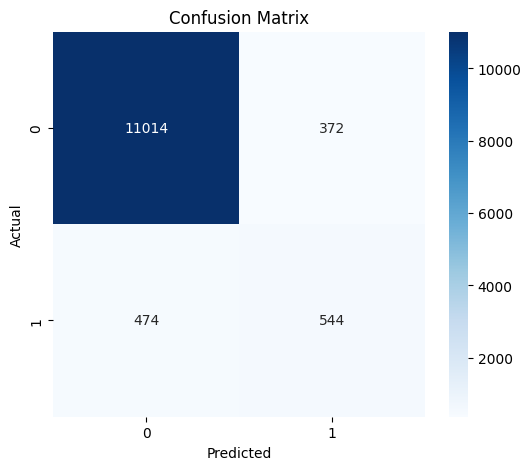

In [83]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [84]:
from sklearn.preprocessing import Binarizer
from sklearn.metrics import accuracy_score

def evaluate_binary_clf(y_true,y_pred):
    print('혼동행렬')
    print(confusion_matrix(y_true,y_pred),'\n')
    print(f'정확도 : {accuracy_score(y_true,y_pred):.4f}/정밀도{precision_score(y_true,y_pred)}/재현율{recall_score(y_true,y_pred)}')

pred_proba = lgbm.predict_proba(X_test)
    

혼동행렬
[[    0 11386]
 [    0  1018]] 

정확도 : 0.0821/정밀도0.08207029990325701/재현율1.0
혼동행렬
[[10282  1104]
 [  299   719]] 

정확도 : 0.8869/정밀도0.39440482720789904/재현율0.706286836935167
혼동행렬
[[10800   586]
 [  414   604]] 

정확도 : 0.9194/정밀도0.507563025210084/재현율0.593320235756385
혼동행렬
[[11014   372]
 [  474   544]] 

정확도 : 0.9318/정밀도0.5938864628820961/재현율0.5343811394891945
혼동행렬
[[11087   299]
 [  509   509]] 

정확도 : 0.9349/정밀도0.629950495049505/재현율0.5
혼동행렬
[[11215   171]
 [  570   448]] 

정확도 : 0.9403/정밀도0.7237479806138933/재현율0.4400785854616896


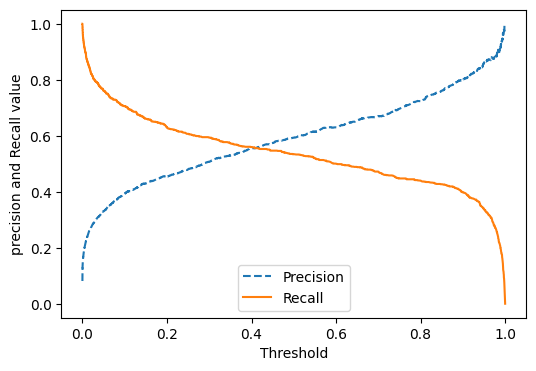

In [85]:

from sklearn.preprocessing import Binarizer
from sklearn.metrics import accuracy_score
pred_proba = lgbm.predict_proba(X_test)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

thresholds = [0.0, 0.1,0.3,0.5,0.6,0.8]

for threshold in thresholds:
    binarizer = Binarizer(threshold=threshold)
    custom_pred = binarizer.fit_transform(pred_proba_1)
    evaluate_binary_clf(y_test, custom_pred)

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_1) # 정밀도, 재현율은 마지막에 극단적으로 낮은 임계치 값을 적용한 값을 보여줌 ([:-1]) 1개 뺴주기

plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1], linestyle='--', label='Precision')
plt.plot(thresholds, recalls[:-1], label = 'Recall')
plt.xlabel('Threshold')
plt.ylabel('precision and Recall value')
plt.legend()
plt.show()

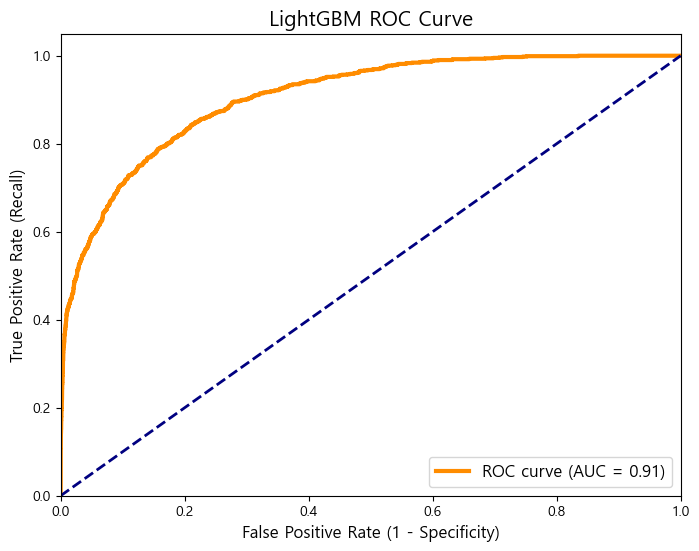

0.9051924829617043

In [98]:
from sklearn.metrics import roc_curve, roc_auc_score


pred_proba = lgbm.predict_proba(X_test)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)


# fpr, tpr, thresholds = roc_curve(y_test, y_pred)

from sklearn.metrics import auc
fpr, tpr, thresholds = roc_curve(y_test, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('LightGBM ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

# plt.savefig('./graphs/RF_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

# roc_auc_score(y_test, pred_proba[:, 1])
roc_auc_score(y_test, pred_proba_1)


       feature  importance
2   평균 상대습도(%)       14406
0     평균기온(°C)       14396
3   최대 풍속(m/s)       13994
4   평균 풍속(m/s)       12930
6         실효습도       12733
8         논_비율        8344
10  도시_산림_인접지수        8322
9         밭_비율        8100
1     일강수량(mm)        4296
7           년도        3948


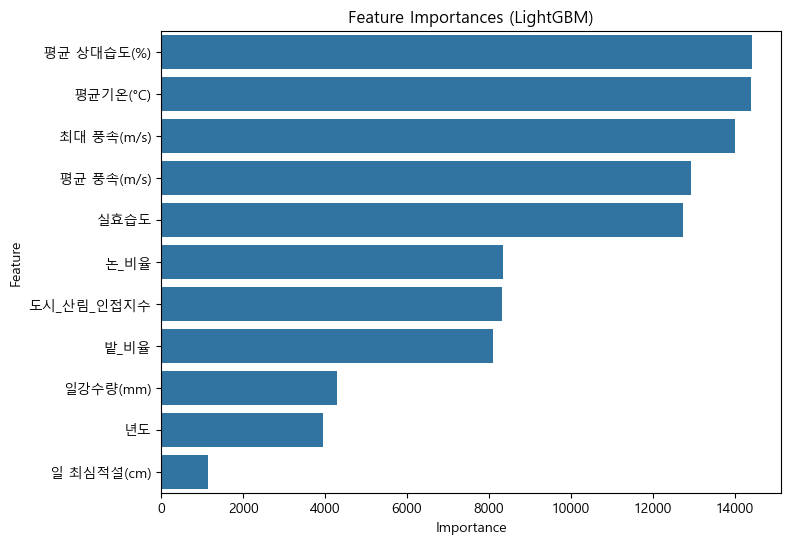

In [101]:
# ==============================
# Feature Importance
# ==============================
importances = lgbm.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

import seaborn as sns
# 한글 설정 (윈도우)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트

plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance_df.head(15),
    x='importance',
    y='feature'
)
plt.title('Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()